In [ ]:
# Install necessary libraries
# We need langchain, langgraph, openai integration, tavily, amadeus, and gradio
!pip install -q --upgrade langchain langgraph langchain_openai tavily-python amadeus python-dotenv gradio langchain_community graphviz


In [ ]:
# Import necessary libraries
import os
import uuid
import getpass
from typing import TypedDict, Annotated, Sequence, List, Tuple, Optional, Any, Union, Literal,  Tuple
import operator
from datetime import date
from IPython.display import display, Markdown, Image
from graphviz import Source
import uuid  # Added for Gradio state

# Langchain specific imports
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool

# LangGraph imports (Updated based on recent versions)
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode  # Preferred way to handle tool execution

# Gradio
import gradio as gr

# Hugging_Face
from huggingface_hub import InferenceClient

from dotenv import load_dotenv


In [ ]:
# Helper function to display markdown nicely
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))

In [ ]:
load_dotenv()

True

In [ ]:
HF_TOKEN = os.environ.get("HUGGINGFACE_API_TOKEN")
client = InferenceClient(token=HF_TOKEN)

In [ ]:
client = InferenceClient(token=HF_TOKEN)

In [ ]:
# Let's define a simple workflow that includes a summarization function

class AgentState(TypedDict):
    input_text: str
    summary: str
    translate: str
    analyze_sentiment: str

In [ ]:
# Let's define the key node, which represents the functions that perform specific tasks in your graph

def summarize_step(state: AgentState) -> AgentState:
    """Create a concise summary of the input text."""

    prompt = f"Please summarize the following text in one sentence that captures the main points: {state['input_text']}"

    result = client.summarization([prompt],model="facebook/bart-large-cnn")

    return {
        **state,
        "summary": result  # Add the summary
    }

In [ ]:
def translate_step(state: AgentState) -> AgentState:

    prompt = f"Please translate the following text from English to Frensh: {state['summary']}"

    result = client.translation([prompt],model="Helsinki-NLP/opus-mt-en-fr")

    return {
        **state,  # Keep the original text
        "translate": result  # Add the translation
    }

In [ ]:
def sentiment_analsis_step(state: AgentState) -> AgentState:

    prompt = f"Please provide sentiment analysis: {state['summary']}"

    result = client.text_classification([prompt],model="lxyuan/distilbert-base-multilingual-cased-sentiments-student")

    return {
        **state,  # Keep the original text
        "analyze_sentiment": result  # Add the translation
    }

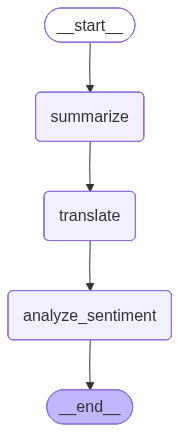

In [ ]:
# Let's define our StateGraph, which is the fundamental building block of LangGraph
# Let's define a stategraph with the "AgentState" we defined earlier
workflow = StateGraph(AgentState)
# Let's add a nodes
workflow.add_node("summarize", summarize_step)
workflow.add_node("translate", translate_step)
workflow.add_node("analyze_sentiment", sentiment_analsis_step)
# Let's define Edges, which define how data flows between nodes
workflow.add_edge("summarize","translate")
workflow.add_edge("translate","analyze_sentiment")
workflow.set_entry_point("summarize")
workflow.compile()

In [ ]:
# Now we are ready to compile and execute the graph

sample_text = """
    Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels.
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation.
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car.
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station.
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """

# Let's compile the graph
graph = workflow.compile()

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
         "summary": "",
         "translate": "",
         "analyze_sentiment": ""}

# Run the graph
result = graph.invoke(initial_state)



SummarizationOutput(summary_text='Electric cars work by using electricity stored in a battery pack to power an electric motor. The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.')


In [ ]:
print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)
print(f"📝 Summary:\n   {result['summary']}\n")
print(f"🌍 Translation (FR):\n   {result['translate']}\n")
print(f"🎭 Sentiment: {result['analyze_sentiment']}")


RESULTS
📝 Summary:
   SummarizationOutput(summary_text='Electric cars work by using electricity stored in a battery pack to power an electric motor. The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.')

🌍 Translation (FR):
   TranslationOutput(translation_text="Veuillez traduire le texte suivant de l'anglais à Frensh: SummarizationOutput(summary_text='Les voitures électriques fonctionnent en utilisant l'électricité stockée dans une batterie pour alimenter un moteur électrique. La batterie est rechargée par branchement de la voiture dans une source d'alimentation externe, comme un chargeur domestique ou une borne de recharge publique.")

🎭 Sentiment: [TextClassificationOutputElement(label='positive', score=0.4809993803501129)]
